In [1]:
import torch
from utils.loading_utils import load_model, get_device
from data_loader.dataset import VoxelGridDataset
from matplotlib import pyplot as plt
from os.path import join, basename
import numpy as np
import json
import argparse
from utils.timers import cuda_timers
import time
import shutil
import os
from psf_depth_reconstructor import PSFDepthReconstructor
from options.inference_options import set_depth_inference_options
from data_loader.dataset import UpsampledFramesDataset
from types import SimpleNamespace
from model.unet import *
from types import SimpleNamespace
import torch
from model.model import E2VIDRecurrentPSF  
from model.model import E2VIDRecurrent
from model import unet as unet_mod          
from torch.utils.data import DataLoader
from data_loader.dataset import SequenceUpsampledFramesDataset
import matplotlib.image as mpimg
from model.unet import compute_event_frame, event_frames_to_voxel_grid
import torch.nn.functional as F

/home/yl3836/.conda/envs/mevent/lib/python3.9/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def plotgrid(stack):
    num_psf = stack.shape[0]  

    ncols = 5  # 원하는대로
    nrows = (num_psf + ncols - 1) // ncols

    fig, axes = plt.subplots(nrows, ncols, figsize=(2*ncols, 2*nrows))

    for i in range(num_psf):
        row, col = divmod(i, ncols)
        ax = axes[row, col]
        ax.imshow(stack[i].detach().numpy(), cmap='gray')
        ax.set_title(f"Depth {i+2}")   # depth index는 2부터일 수도 있으니 맞게 조절
        ax.axis('off')

    for i in range(num_psf, nrows*ncols):
        row, col = divmod(i, ncols)
        axes[row, col].axis('off')

    plt.tight_layout()
    plt.show()

def _to_device(x, device):
    if isinstance(x, torch.Tensor):
        return x.to(device, non_blocking=True)
    if isinstance(x, dict):
        return {k: _to_device(v, device) for k, v in x.items()}
    if isinstance(x, (list, tuple)):
        return type(x)(_to_device(v, device) for v in x)
    return x

def collate_keep_sequence(batch, device):
    # batch: [N] where each item is a sequence [L] of dicts
    return _to_device(batch, device)

In [3]:
%load_ext autoreload
%autoreload 2

PATH_TO_MODEL = '/home/yl3836/mono_event/rpg_e2depth/e2depth/saved/0923_off_P21_D30_delta_0_5/example_psf/model_best.pth.tar'
tag = " [delta_1_0]"

# PATH_TO_MODEL = '/home/yl3836/mono_event/rpg_e2depth/e2depth/saved/0923_off_P21_D30_rotated_0_5_1_0/example_psf/model_best.pth.tar'
# tag = " [rotated_0_5_1_0]"
#PATH_TO_MODEL = '/home/yl3836/mono_event/rpg_e2depth/e2depth/saved/0912_off_P21_D30_rotated_0_5_2_0/example_psf/model_best.pth.tar'
BASE_FOLDER = '/home/yl3836/DENSE/valid_upsampled/valid_sequence_00_town06/'
#BASE_FOLDER = '/home/yl3836/DENSE/train_upsampled/train_sequence_03_town04/'
USE_GPU = True

args = SimpleNamespace(
    path_to_model=PATH_TO_MODEL,
    base_folder=BASE_FOLDER,
    use_gpu=USE_GPU,
)

PATH = args.path_to_model
ckpt = torch.load(PATH, map_location='cpu')

#### Same config as used in training
cfg = dict(num_bins=5, skip_type='sum', recurrent_block_type='convlstm',
           num_encoders=3, base_num_channels=32,
           num_residual_blocks=2, use_upsample_conv=True, norm='none', psf_init='random')



#### Top-level model class
model = E2VIDRecurrentPSF(cfg)


######## Loading the weights
model.load_state_dict(ckpt['state_dict'])  

######## Evaluation mode : disable dropout
model.eval()


#### Load optimized psf
net = model.unetrecurrentpsf

Using UpsampleConvLayer (slow, but no checkerboard artefacts)


/home/yl3836/mono_event/rpg_e2depth/e2depth/model/unet.py:51: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  th = torch.tensor(theta_deg, device=device, dtype=dtype) * torch.pi / 180
/home/yl3836/mono_event/rpg_e2depth/e2depth/model/unet.py:400: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  psf_list.append(torch.tensor(conv,dtype = torch.float32))


In [4]:
device = 'cpu' 

unet_mod.gpu = device   # used by UNetRecurrentPSF to move tensors
model.to(device).eval() 

#### load dataset
ds = SequenceUpsampledFramesDataset(
    base_folder=BASE_FOLDER,
    event_folder='',
    depth_folder='imgs',
    frame_folder='frames',
    sequence_length=20, step_size=1, normalize=True
)

loader = DataLoader(
    ds, batch_size=1, shuffle=False,
    collate_fn=lambda b: collate_keep_sequence(b, device),
    num_workers=0, pin_memory=False
)

batch = next(iter(loader))                

##### Forming sequence, copied from lstm.py
sequence = list(map(list, zip(*batch)))   
cur_input   = sequence[0]                 
prev_states = None

#### This is the forward model of top-level model
with torch.no_grad():
    voxel, frame, pred, states, timing = model.unetrecurrentpsf(cur_input, prev_states, downsample=False, measure_time = True)
print(voxel.shape, frame.shape, pred.shape)

torch.Size([1, 5, 260, 346]) torch.Size([9, 1, 260, 346]) torch.Size([1, 1, 260, 346])


Text(0.5, 1.0, 'Ground Truth Depth Map')

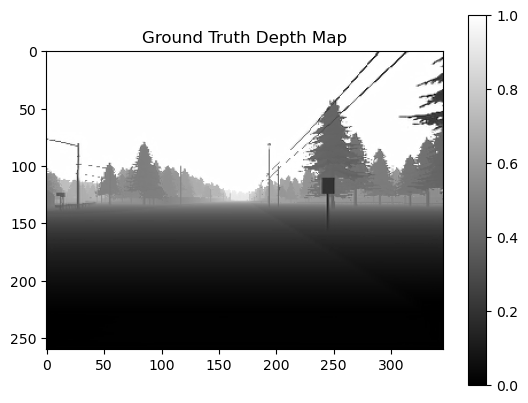

In [5]:
# GT depth map
plt.imshow(frame[1].squeeze().squeeze(), cmap = 'gray', vmin=0, vmax=1)  # GT depth map
plt.colorbar()
plt.title("Ground Truth Depth Map")

Text(0.5, 1.0, 'Predicted Depth Map')

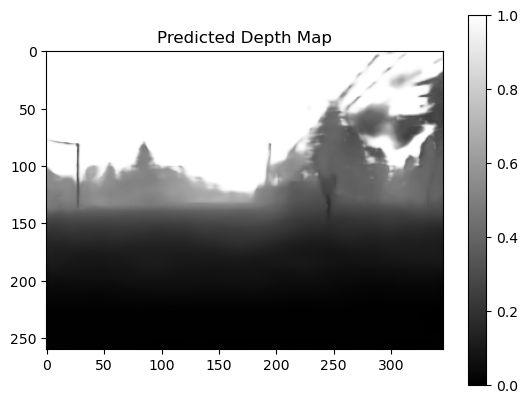

In [6]:
#### Prediction of the network
plt.imshow(pred.squeeze().squeeze(), cmap = 'gray', vmin=0, vmax=1)  # Predicted depth map
plt.colorbar()
plt.title("Predicted Depth Map")

In [7]:
#### Choosing one sample
l, n = 0, 0
item = sequence[l][n]         

frames = item['frames'].to(device)          # [T, 1, H, W], already normalized [0,1] by the dataset
stamps = item['stamps'].to(device).float()  # [T] timestamps
frame = item['frame'].to(device)    # depth in log scale
md     = item['metric_depth'].to(device) 

print(frames.shape, frame.shape, md.shape, stamps.shape)

torch.Size([9, 1, 260, 346]) torch.Size([9, 1, 260, 346]) torch.Size([9, 1, 260, 346]) torch.Size([9])


In [8]:
# Setting up self inorder to run forward in DepthDependentPSFLayer class
self = model.unetrecurrentpsf.psf_layer

# setting up inputs for UnetRecurrentPSF -> DepthDependentPSFLayer
image = frames

In [9]:
#### Copied from DepthDependentPSFLayer forward
image = image.squeeze(0)
T, _, H, W = image.shape
D = self.num_depths
k = self.psf_size

rotated = self.psfs

rotated = (rotated-rotated.min())/(rotated.max() - rotated.min())
rotated = rotated + 1e-6
rotated = torch.clip(rotated, 1e-6, 1.0)

psfs = rotated

#### Copied from UnetRecurrentPSF forward
min_depth = 2.0
max_depth = 31.0

depth = md
depth = depth * (max_depth - min_depth) + min_depth

depth_bins = depth

In [10]:
lower = torch.arange(min_depth, max_depth+1)
higher = lower + 1

print(lower)
print(higher)

lower = lower.unsqueeze(-1).unsqueeze(-1) # Shape [1,1,15] for broadcast
higher = higher.unsqueeze(-1).unsqueeze(-1) # Shape [1,1,15] for broadcast
mask = ((depth_bins >= lower) & (depth_bins < higher)).float()  

masked_frames = mask.unsqueeze(0) * frames
masked_frames = masked_frames.squeeze()
C = masked_frames.shape[1]
out = F.conv2d(masked_frames, psfs, padding="same", groups=C)
print(out.shape)

convolved_sum = out.sum(1)

tensor([ 2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12., 13., 14., 15.,
        16., 17., 18., 19., 20., 21., 22., 23., 24., 25., 26., 27., 28., 29.,
        30., 31.])
tensor([ 3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12., 13., 14., 15., 16.,
        17., 18., 19., 20., 21., 22., 23., 24., 25., 26., 27., 28., 29., 30.,
        31., 32.])
torch.Size([9, 30, 260, 346])


In [11]:
def compute_event_frame(diff):
    """
    Implements equation (3) from "Differentiable Event Stream Simulator for Non-Rigid 3D Tracking.
    The parameter values for eps and w are chosen by my best guess. C is chosen to be what was used
    in the Vid2Events codebase for their event simulation method.
    """

    eps = 1e-6
    C = 0.05
    w = 100
    return ((diff + eps) / (torch.abs(diff) + eps)) * (1 / (1 + torch.exp(-w*torch.abs(diff)+w*C)))

convolved_sum.shape : torch.Size([9, 260, 346])
diffs.shape : torch.Size([8, 260, 346])


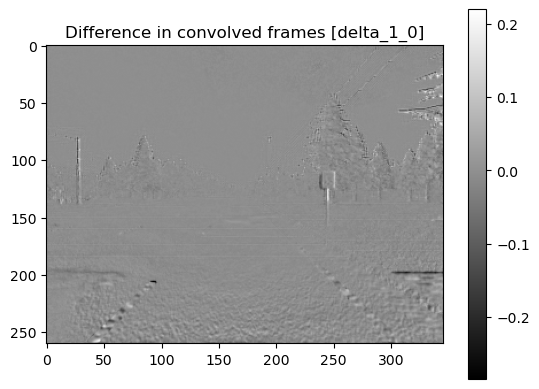

In [12]:
epsilon = 1e-6
log_frames = torch.log(convolved_sum + epsilon)
print(f"convolved_sum.shape : {convolved_sum.shape}")
diffs = log_frames[1:] - log_frames[:-1] 
print(f"diffs.shape : {diffs.shape}")

plt.imshow(diffs[0].detach().numpy(), cmap = 'gray')
plt.title('Difference in convolved frames'+tag)
plt.colorbar()

event_frames.shape : torch.Size([8, 260, 346])


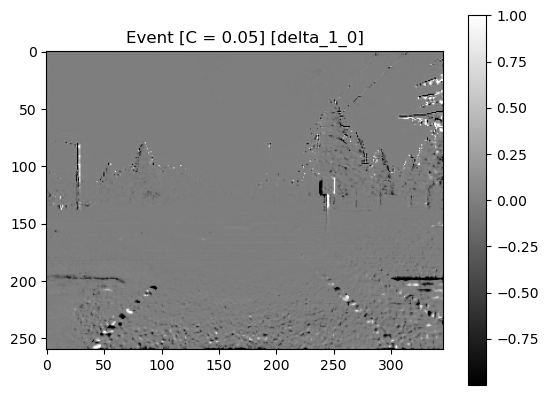

In [13]:
event_frames = compute_event_frame(diffs) 
print(f"event_frames.shape : {event_frames.shape}")

plt.imshow(event_frames[0].detach().numpy(), cmap = 'gray')
plt.title('Event [C = 0.05]'+tag)
plt.colorbar()

In [14]:
test_event = event_frames[0].detach().numpy()

(260, 346)


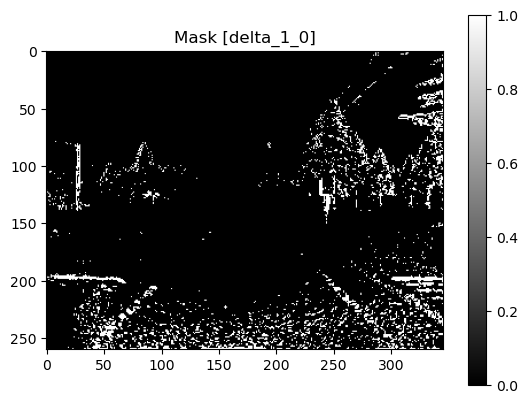

In [15]:
vals = np.asarray(test_event)
print(vals.shape)
mask = np.abs(vals) > 0.1

plt.imshow(mask, cmap = 'gray')
plt.title('Mask'+tag)
plt.colorbar()

In [16]:
gt_test = frame[1].squeeze().squeeze()
print(gt_test.shape)

mask_test = torch.from_numpy(mask)
print(mask_test.shape)

pred_test = pred.squeeze().squeeze()
print(pred_test.shape)

torch.Size([260, 346])
torch.Size([260, 346])
torch.Size([260, 346])


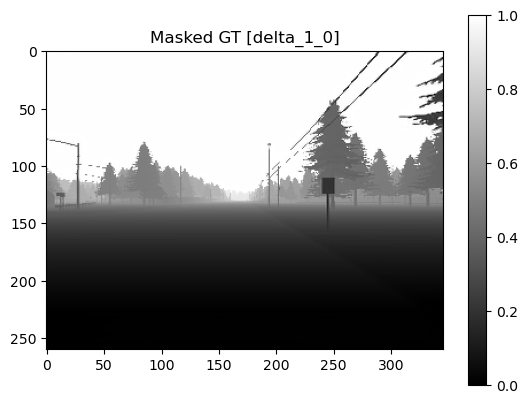

In [17]:
plt.imshow(gt_test.detach().numpy(), cmap = 'gray', vmin=0, vmax=1)
plt.title('Masked GT'+tag)
plt.colorbar()

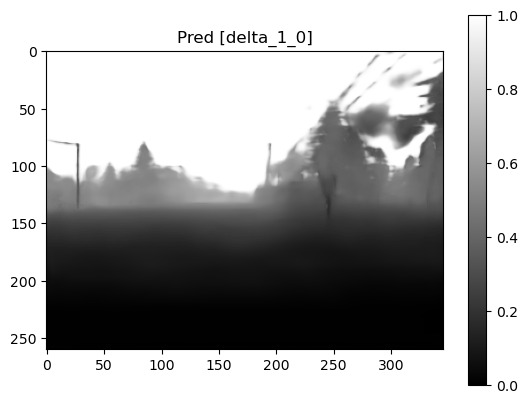

In [18]:
plt.imshow(pred_test.detach().numpy(), cmap = 'gray', vmin=0, vmax=1)
plt.title('Pred'+tag)
plt.colorbar()

In [19]:
mse_full = F.mse_loss(pred_test, gt_test)
print("MSE (full image):", mse_full.item())

MSE (full image): 0.012771558947861195


In [20]:
mse_val = mse_full.item()
if mse_val == 0:
    psnr = float('inf')
else:
    psnr = 20 * math.log10(1.0 / math.sqrt(mse_val))  # assuming pixel range [0,1]
print("PSNR:", psnr)

PSNR: 18.937560877694157


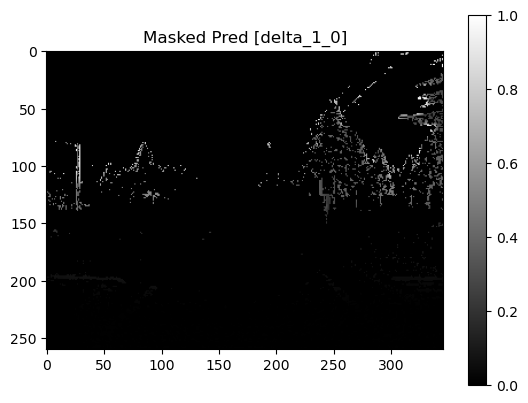

In [21]:
masked_pred = mask_test * pred_test
masked_gt = mask_test * gt_test
plt.imshow(masked_pred.detach().numpy(), cmap = 'gray', vmin=0, vmax=1)
plt.title('Masked Pred'+tag)
plt.colorbar()

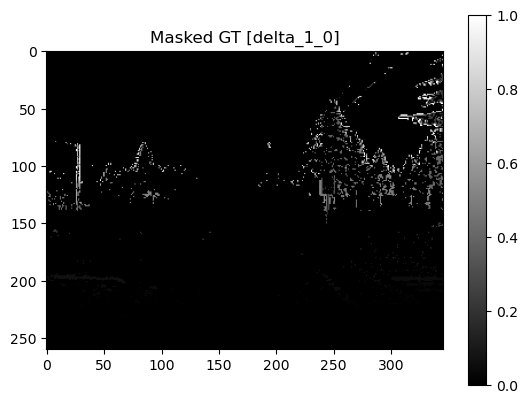

In [22]:
plt.imshow(masked_gt.detach().numpy(), cmap = 'gray', vmin=0, vmax=1)
plt.title('Masked GT'+tag)
plt.colorbar()

In [23]:
mse_full = F.mse_loss(masked_pred, masked_gt)
print("MSE (full image):", mse_full.item())

MSE (full image): 0.0010769050568342209


In [24]:
mse_val = mse_full.item()
if mse_val == 0:
    psnr = float('inf')
else:
    psnr = 20 * math.log10(1.0 / math.sqrt(mse_val))  # assuming pixel range [0,1]
print("PSNR:", psnr)

PSNR: 29.678225837127556


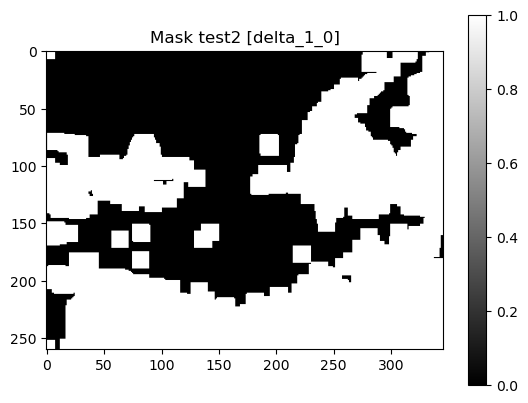

In [25]:
from scipy.ndimage import maximum_filter
mask_test2 = maximum_filter(mask.astype(np.uint8), size=15) > 0
plt.imshow(mask_test2, cmap = 'gray')
plt.title('Mask test2'+tag)
plt.colorbar()

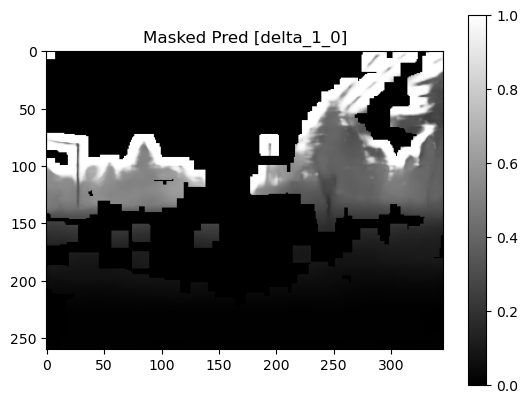

In [26]:
mask_test2 = torch.from_numpy(mask_test2)
masked_pred2 = mask_test2 * pred_test
masked_gt2 = mask_test2 * gt_test
plt.imshow(masked_pred2.detach().numpy(), cmap = 'gray', vmin=0, vmax=1)
plt.title('Masked Pred'+tag)
plt.colorbar()

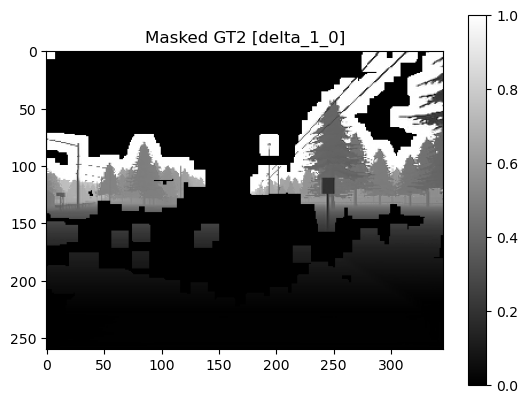

In [27]:
plt.imshow(masked_gt2.detach().numpy(), cmap = 'gray', vmin=0, vmax=1)
plt.title('Masked GT2'+tag)
plt.colorbar()

In [28]:
mse_full2 = F.mse_loss(masked_pred2, masked_gt2)
print("MSE (full image):", mse_full2.item())

mse_val = mse_full2.item()
if mse_val == 0:
    psnr = float('inf')
else:
    psnr = 20 * math.log10(1.0 / math.sqrt(mse_val))  # assuming pixel range [0,1]
print("PSNR:", psnr)

MSE (full image): 0.009151439182460308
PSNR: 20.38510602124652


In [29]:
import numpy as np
import torch
from scipy.ndimage import rotate, gaussian_filter

# ... inside your class / method ...
if self.psf_init == 'two_rotated':
    angles = torch.linspace(0, 90, steps=30)  # or whatever range you want
    psf_list = []

    # --------- simple knobs ----------
    separation_px = 6    # distance between the two peaks (in pixels)
    sigma = 0.5          # gaussian blur to turn impulses into gaussians
    # ---------------------------------

    # Build a base image with two impulses placed horizontally around center
    base = np.zeros((psf_size, psf_size), dtype=np.float32)
    center = psf_size // 2

    # Use integer offsets for simplicity; psf_size odd is recommended
    off = int(round(separation_px / 2))
    left_x  = center - off
    right_x = center + off

    # Guard against going out of bounds if separation_px is large
    left_x  = max(0, min(psf_size - 1, left_x))
    right_x = max(0, min(psf_size - 1, right_x))

    base[center, left_x]  = 1.0
    base[center, right_x] = 1.0

    # Turn the impulses into two Gaussians
    gauss_two = gaussian_filter(base, sigma=sigma)

    # Rotate for each angle and normalize
    for theta in angles.tolist():
        rotated = rotate(gauss_two, angle=float(theta), reshape=False, order=1, mode='nearest')
        rotated = rotated / (rotated.sum() + 1e-12)  # keep it normalized
        psf_list.append(torch.from_numpy(rotated.astype(np.float32)))

    # (optional) stack to [num_depths, H, W]
    psf_stack = torch.stack(psf_list, dim=0)
